In [183]:
import os
from pathlib import Path
import pandas as pd, torch, numpy as np
import matplotlib.pyplot as plt

In [184]:
np.set_printoptions(linewidth=140)
torch.set_printoptions(linewidth=140, sci_mode=False, edgeitems=7)
pd.set_option('display.width', 140)

# Data and stuff

In [185]:
df = pd.read_csv("../../../data/cleaned_data/cleaned_pull_count.csv").drop("Unnamed: 0", axis=1)

In [186]:
df

,pulled_count_TARGET_VARIABLE,rarity,weapon,element,region,asc_stat_bonus_category,3D-model,lvl_90_HP,lvl_90_ATK,lvl_90_DEF,...,is_archon,is_standard_banner,role_Off_Field,role_On_Field,role_Support,role_Survivability,role_DPS,duplicate_rate,c6_rate,avg_copies_per_player
0,1338383,4,Sword,Anemo,Fontaine,Anemo DMG Bonus,Medium Female,12397,232,712,...,0,1,1,0,0,0,1,0.774796,0.036392,4.440421
1,93049,5,Catalyst,Electro,Natlan,CRIT Rate,Medium Female,12699,356,782,...,0,0,0,1,0,0,1,0.256102,0.036035,1.344270
2,4277322,4,Claymore,Cryo,Liyue,ATK%,Medium Male,10984,223,648,...,0,1,1,0,1,0,1,0.688872,0.023110,3.214113
3,717953,5,Bow,Dendro,Sumeru,Dendro DMG Bonus,Medium Male,10850,268,630,...,0,1,0,1,0,0,1,0.050633,0.001336,1.053333
4,1341413,5,Sword,Anemo,Mondstadt,Healing Bonus,Tall Female,14695,239,769,...,0,1,1,0,0,1,0,0.036889,0.000031,1.038302
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98,420336,5,Catalyst,Hydro,Inazuma,Hydro DMG Bonus,Medium Female,13471,234,657,...,0,0,1,0,1,1,0,0.110985,0.006595,1.124840
99,340340,5,Claymore,Cryo,Mondstadt,CRIT DMG,Tall Female,13226,342,751,...,0,0,0,1,0,0,1,0.200414,0.034060,1.250648
100,181138,5,Catalyst,Pyro,Mondstadt,Pyro DMG Bonus,Short Female,10287,311,615,...,0,0,0,1,0,0,1,0.109530,0.004869,1.123002
101,400978,5,Bow,Cryo,Liyue,CRIT DMG,Medium Female,9797,335,630,...,0,0,0,1,0,0,1,0.166468,0.018976,1.199714


In [187]:
df.columns

Index(['pulled_count_TARGET_VARIABLE', 'rarity', 'weapon', 'element', 'region', 'asc_stat_bonus_category', '3D-model', 'lvl_90_HP',
       'lvl_90_ATK', 'lvl_90_DEF', 'months_since_release', 'num_banners', 'is_archon', 'is_standard_banner', 'role_Off_Field',
       'role_On_Field', 'role_Support', 'role_Survivability', 'role_DPS', 'duplicate_rate', 'c6_rate', 'avg_copies_per_player'],
      dtype='str')

In [188]:
df.sort_values(by='months_since_release', ascending=False, inplace=True, ignore_index=True)

In [189]:
df["months_since_release"]

0      63.081967
1      63.081967
2      63.081967
3      63.081967
4      63.081967
         ...    
98      3.803279
99      3.147541
100     2.426230
101     1.049180
102     1.049180
Name: months_since_release, Length: 103, dtype: float64

In [190]:
df

,pulled_count_TARGET_VARIABLE,rarity,weapon,element,region,asc_stat_bonus_category,3D-model,lvl_90_HP,lvl_90_ATK,lvl_90_DEF,...,is_archon,is_standard_banner,role_Off_Field,role_On_Field,role_Support,role_Survivability,role_DPS,duplicate_rate,c6_rate,avg_copies_per_player
0,4277322,4,Claymore,Cryo,Liyue,ATK%,Medium Male,10984,223,648,...,0,1,1,0,1,0,1,0.688872,0.023110,3.214113
1,1342803,5,Sword,Electro,Liyue,CRIT DMG,Medium Female,13103,323,799,...,0,1,0,1,0,0,1,0.037670,0.000016,1.039145
2,1341413,5,Sword,Anemo,Mondstadt,Healing Bonus,Tall Female,14695,239,769,...,0,1,1,0,0,1,0,0.036889,0.000031,1.038302
3,6183960,4,Sword,Hydro,Liyue,ATK%,Medium Male,10222,202,758,...,0,1,1,0,0,1,1,0.768028,0.035901,4.310870
4,1334757,5,Sword,Cryo,Liyue,Healing Bonus,Short Female,12368,287,922,...,0,1,1,0,0,1,0,0.037775,0.000026,1.039258
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98,419747,4,Claymore,Hydro,Nod-Krai,Elemental Mastery,Short Female,11201,242,607,...,0,1,1,0,0,0,1,0.864923,0.050130,7.403206
99,134582,5,Polearm,Electro,Nod-Krai,CRIT DMG,Tall Male,12491,352,809,...,0,0,0,1,0,0,1,0.393106,0.041818,1.647734
100,72343,5,Catalyst,Dendro,Nod-Krai,CRIT DMG,Tall Female,12704,344,799,...,0,0,0,1,0,0,1,0.242041,0.059992,1.319333
101,183773,4,Bow,Anemo,Nod-Krai,Healing Bonus,Medium Female,9646,223,580,...,0,1,1,0,1,1,0,0.820006,0.062278,5.555747


In [191]:
df_encoded = pd.get_dummies(df[["rarity", "weapon", "element", "3D-model", "is_archon", "is_standard_banner"]], columns=["weapon", "element", "3D-model"], prefix=["weapon", "element", "model"]).astype(float)

In [192]:
df_encoded

,rarity,is_archon,is_standard_banner,weapon_Bow,weapon_Catalyst,weapon_Claymore,weapon_Polearm,weapon_Sword,element_Anemo,element_Cryo,element_Dendro,element_Electro,element_Geo,element_Hydro,element_Pyro,model_Medium Female,model_Medium Male,model_Short Female,model_Tall Female,model_Tall Male
0,4.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,5.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,5.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,4.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4,5.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98,4.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
99,5.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
100,5.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
101,4.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [193]:
df_encoded.columns

Index(['rarity', 'is_archon', 'is_standard_banner', 'weapon_Bow', 'weapon_Catalyst', 'weapon_Claymore', 'weapon_Polearm', 'weapon_Sword',
       'element_Anemo', 'element_Cryo', 'element_Dendro', 'element_Electro', 'element_Geo', 'element_Hydro', 'element_Pyro',
       'model_Medium Female', 'model_Medium Male', 'model_Short Female', 'model_Tall Female', 'model_Tall Male'],
      dtype='str')

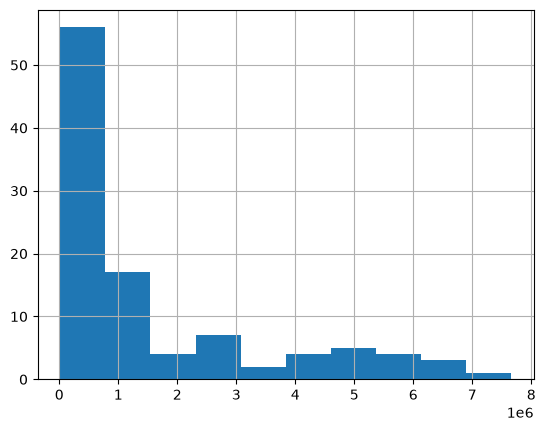

In [194]:
df["pulled_count_TARGET_VARIABLE"].hist();

In [195]:
df["pulled_count_TARGET_VARIABLE"] = np.log(df["pulled_count_TARGET_VARIABLE"])

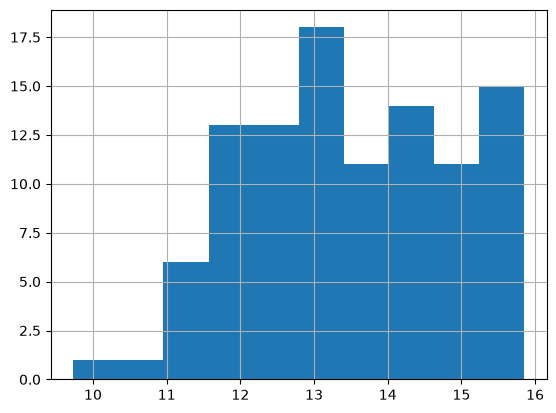

In [196]:
df["pulled_count_TARGET_VARIABLE"].hist();

In [197]:
df["pulled_count_TARGET_VARIABLE"]

0      15.268838
1      14.110270
2      14.109234
3      15.637469
4      14.104260
         ...    
98     12.947407
99     11.809929
100    11.189174
101    12.121457
102    11.101568
Name: pulled_count_TARGET_VARIABLE, Length: 103, dtype: float64

In [198]:
from torch import tensor
device = 'cuda' if torch.cuda.is_available() else 'cpu'
t_dep = tensor(df["pulled_count_TARGET_VARIABLE"], dtype=torch.float).to(device)
max_t_dep = t_dep.max()
t_dep = t_dep/max_t_dep
print(max_t_dep)
t_dep

tensor(15.8514, device='cuda:0')


tensor([0.9632, 0.8902, 0.8901, 0.9865, 0.8898, 0.8900, 0.9713, 0.9458, 0.9834, 0.8901, 1.0000, 0.9772, 0.9571, 0.9680, 0.9801, 0.7935,
        0.9756, 0.7638, 0.8104, 0.9923, 0.9551, 0.8487, 0.7810, 0.8139, 0.8166, 0.8572, 0.9852, 0.9904, 0.8036, 0.8627, 0.8492, 0.8095,
        0.9701, 0.9638, 0.8842, 0.8169, 0.9827, 0.8092, 0.9276, 0.7926, 0.9570, 0.8270, 0.8071, 0.8424, 0.9285, 0.9310, 0.9365, 0.8507,
        0.9304, 0.9309, 0.7699, 0.7765, 0.8446, 0.9020, 0.9285, 0.8065, 0.9181, 0.7783, 0.8290, 0.8880, 0.8770, 0.7402, 0.8630, 0.8900,
        0.7300, 0.8773, 0.8155, 0.7496, 0.8980, 0.8462, 0.7754, 0.9100, 0.7623, 0.8967, 0.7103, 0.8117, 0.7559, 0.8781, 0.6658, 0.6954,
        0.9003, 0.7574, 0.7491, 0.7925, 0.8645, 0.7461, 0.7977, 0.7762, 0.8263, 0.6140, 0.7218, 0.8423, 0.8286, 0.7384, 0.8328, 0.7707,
        0.6973, 0.7444, 0.8168, 0.7450, 0.7059, 0.7647, 0.7004], device='cuda:0')

In [199]:
t_dep.shape

torch.Size([103])

In [200]:
t_indep = tensor(df[["rarity"]].values, dtype=torch.float).to(device)
t_indep

tensor([[4.],
        [5.],
        [5.],
        [4.],
        [5.],
        [5.],
        [4.],
        [4.],
        [4.],
        [5.],
        [4.],
        [4.],
        [4.],
        [4.],
        [4.],
        [5.],
        [4.],
        [5.],
        [5.],
        [4.],
        [4.],
        [5.],
        [5.],
        [5.],
        [5.],
        [5.],
        [4.],
        [4.],
        [5.],
        [5.],
        [5.],
        [5.],
        [4.],
        [4.],
        [5.],
        [5.],
        [4.],
        [5.],
        [4.],
        [5.],
        [4.],
        [5.],
        [5.],
        [5.],
        [4.],
        [4.],
        [4.],
        [5.],
        [4.],
        [4.],
        [5.],
        [5.],
        [5.],
        [4.],
        [4.],
        [5.],
        [4.],
        [5.],
        [5.],
        [4.],
        [4.],
        [5.],
        [4.],
        [4.],
        [5.],
        [4.],
        [5.],
        [5.],
        [4.],
        [5.],
        [5.],
      

In [201]:
t_indep.shape

torch.Size([103, 1])

In [202]:
torch.manual_seed(442)

n_coeff = t_indep.shape[1]
coeffs = (torch.rand(n_coeff)-0.3).to(device)
coeffs

tensor([-0.2629], device='cuda:0')

In [203]:
coeffs.shape

torch.Size([1])

In [204]:
result = t_indep*coeffs
result

tensor([[-1.0516],
        [-1.3145],
        [-1.3145],
        [-1.0516],
        [-1.3145],
        [-1.3145],
        [-1.0516],
        [-1.0516],
        [-1.0516],
        [-1.3145],
        [-1.0516],
        [-1.0516],
        [-1.0516],
        [-1.0516],
        [-1.0516],
        [-1.3145],
        [-1.0516],
        [-1.3145],
        [-1.3145],
        [-1.0516],
        [-1.0516],
        [-1.3145],
        [-1.3145],
        [-1.3145],
        [-1.3145],
        [-1.3145],
        [-1.0516],
        [-1.0516],
        [-1.3145],
        [-1.3145],
        [-1.3145],
        [-1.3145],
        [-1.0516],
        [-1.0516],
        [-1.3145],
        [-1.3145],
        [-1.0516],
        [-1.3145],
        [-1.0516],
        [-1.3145],
        [-1.0516],
        [-1.3145],
        [-1.3145],
        [-1.3145],
        [-1.0516],
        [-1.0516],
        [-1.0516],
        [-1.3145],
        [-1.0516],
        [-1.0516],
        [-1.3145],
        [-1.3145],
        [-1.

In [205]:
max_values, indices = t_indep.max(axis=0)
t_indep = t_indep/max_values

In [206]:
max_values

tensor([5.], device='cuda:0')

In [207]:
t_indep

tensor([[0.8000],
        [1.0000],
        [1.0000],
        [0.8000],
        [1.0000],
        [1.0000],
        [0.8000],
        [0.8000],
        [0.8000],
        [1.0000],
        [0.8000],
        [0.8000],
        [0.8000],
        [0.8000],
        [0.8000],
        [1.0000],
        [0.8000],
        [1.0000],
        [1.0000],
        [0.8000],
        [0.8000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [0.8000],
        [0.8000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [0.8000],
        [0.8000],
        [1.0000],
        [1.0000],
        [0.8000],
        [1.0000],
        [0.8000],
        [1.0000],
        [0.8000],
        [1.0000],
        [1.0000],
        [1.0000],
        [0.8000],
        [0.8000],
        [0.8000],
        [1.0000],
        [0.8000],
        [0.8000],
        [1.0000],
        [1.0000],
        [1.0000],
        [0.8000],
        [0.8000],
        [1

In [208]:
result = t_indep*coeffs
result

tensor([[-0.2103],
        [-0.2629],
        [-0.2629],
        [-0.2103],
        [-0.2629],
        [-0.2629],
        [-0.2103],
        [-0.2103],
        [-0.2103],
        [-0.2629],
        [-0.2103],
        [-0.2103],
        [-0.2103],
        [-0.2103],
        [-0.2103],
        [-0.2629],
        [-0.2103],
        [-0.2629],
        [-0.2629],
        [-0.2103],
        [-0.2103],
        [-0.2629],
        [-0.2629],
        [-0.2629],
        [-0.2629],
        [-0.2629],
        [-0.2103],
        [-0.2103],
        [-0.2629],
        [-0.2629],
        [-0.2629],
        [-0.2629],
        [-0.2103],
        [-0.2103],
        [-0.2629],
        [-0.2629],
        [-0.2103],
        [-0.2629],
        [-0.2103],
        [-0.2629],
        [-0.2103],
        [-0.2629],
        [-0.2629],
        [-0.2629],
        [-0.2103],
        [-0.2103],
        [-0.2103],
        [-0.2629],
        [-0.2103],
        [-0.2103],
        [-0.2629],
        [-0.2629],
        [-0.

In [209]:
result.shape

torch.Size([103, 1])

In [210]:
preds = result.sum(axis=1)
preds

tensor([-0.2103, -0.2629, -0.2629, -0.2103, -0.2629, -0.2629, -0.2103, -0.2103, -0.2103, -0.2629, -0.2103, -0.2103, -0.2103, -0.2103,
        -0.2103, -0.2629, -0.2103, -0.2629, -0.2629, -0.2103, -0.2103, -0.2629, -0.2629, -0.2629, -0.2629, -0.2629, -0.2103, -0.2103,
        -0.2629, -0.2629, -0.2629, -0.2629, -0.2103, -0.2103, -0.2629, -0.2629, -0.2103, -0.2629, -0.2103, -0.2629, -0.2103, -0.2629,
        -0.2629, -0.2629, -0.2103, -0.2103, -0.2103, -0.2629, -0.2103, -0.2103, -0.2629, -0.2629, -0.2629, -0.2103, -0.2103, -0.2629,
        -0.2103, -0.2629, -0.2629, -0.2103, -0.2103, -0.2629, -0.2103, -0.2103, -0.2629, -0.2103, -0.2629, -0.2629, -0.2103, -0.2629,
        -0.2629, -0.2103, -0.2629, -0.2103, -0.2629, -0.2629, -0.2629, -0.2103, -0.2629, -0.2629, -0.2103, -0.2629, -0.2629, -0.2629,
        -0.2103, -0.2629, -0.2629, -0.2629, -0.2103, -0.2629, -0.2629, -0.2103, -0.2103, -0.2629, -0.2103, -0.2629, -0.2629, -0.2629,
        -0.2103, -0.2629, -0.2629, -0.2103, -0.2629], device='

In [211]:
print(preds.shape, t_dep.shape)

torch.Size([103]) torch.Size([103])


In [212]:
loss = ((preds-t_dep)**2).mean()
loss

tensor(1.1877, device='cuda:0')

In [213]:
def calc_preds(coeffs, indeps): return (indeps*coeffs).sum(axis=1)
def calc_loss(coeffs, indeps, deps): return ((calc_preds(coeffs, indeps)-deps)**2).mean()

In [214]:
coeffs.requires_grad_()

tensor([-0.2629], device='cuda:0', requires_grad=True)

In [215]:
loss = calc_loss(coeffs, t_indep, t_dep)
loss.backward()

In [216]:
loss

tensor(1.1877, device='cuda:0', grad_fn=<MeanBackward0>)

In [217]:
coeffs.grad

tensor([-1.9772], device='cuda:0')

In [218]:
with torch.no_grad():
    coeffs.sub_(coeffs.grad*0.01)
    loss = calc_loss(coeffs, t_indep, t_dep)
    print(loss)

tensor(1.1489, device='cuda:0')


In [219]:
trn_split = np.arange(0, 78)
val_split = np.arange(78, 103)

In [220]:
trn_indep, val_indep = t_indep[trn_split], t_indep[val_split]
trn_dep, val_dep = t_dep[trn_split], t_dep[val_split]

In [221]:
trn_indep.shape, val_indep.shape, trn_dep.shape, val_dep.shape, coeffs.shape

(torch.Size([78, 1]),
 torch.Size([25, 1]),
 torch.Size([78]),
 torch.Size([25]),
 torch.Size([1]))

In [222]:
def update_coeffs(coeffs, lr):
    return coeffs.sub_(coeffs.grad*lr)

In [223]:
def one_epoch(coeffs, lr, losses):
    loss=calc_loss(coeffs, trn_indep, trn_dep)
    loss.backward()
    with torch.no_grad(): update_coeffs(coeffs, lr)
    losses.append(loss.item())
    print(f"{loss:.3f}", end="; ")

In [224]:
def init_coeffs(): return (torch.rand(n_coeff)-0.3).to(device).requires_grad_()

In [225]:
def train_model(epochs=30, lr=0.01):
    torch.manual_seed(442)
    coeffs=init_coeffs()
    losses = []
    for i in range(epochs): one_epoch(coeffs, lr, losses)
    plt.plot(losses)
    return coeffs

1.241; 1.201; 1.124; 1.014; 0.880; 0.729; 0.573; 0.420; 0.282; 0.168; 

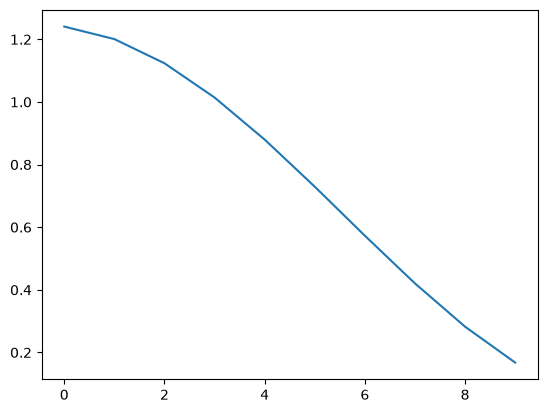

In [226]:
coeffs = train_model(epochs=10,lr=0.01)

In [227]:
print(coeffs)

tensor([0.6851], device='cuda:0', requires_grad=True)


In [228]:
preds = calc_preds(coeffs, val_indep)

In [229]:
ss_res = ((preds - val_dep)**2).sum()
ss_tot = ((val_dep - val_dep.mean())**2).sum()
r2 = 1-(ss_res/ss_tot)
r2

tensor(-6.0224, device='cuda:0', grad_fn=<RsubBackward1>)

In [230]:
def r2(coeffs): return 1-((((calc_preds(coeffs, val_indep) - val_dep)**2).sum())/(((val_dep - val_dep.mean())**2).sum()))

In [231]:
r2(coeffs)

tensor(-6.0224, device='cuda:0', grad_fn=<RsubBackward1>)

In [232]:
def calc_preds(coeffs, indeps): return (indeps@coeffs)

In [250]:
def init_coeffs(): return (torch.rand(n_coeff,1)*0.01).to(device).requires_grad_()

In [251]:
trn_dep = trn_dep[:, None]
val_dep = val_dep[:, None]

In [252]:
trn_dep.shape, val_dep.shape, trn_indep.shape, val_indep.shape

(torch.Size([78, 1, 1]),
 torch.Size([25, 1, 1]),
 torch.Size([78, 1]),
 torch.Size([25, 1]))

In [253]:
coeffs = train_model(39,0.001)

ValueError: not enough values to unpack (expected 4, got 1)

In [254]:
coeffs

(tensor([[-0.0169, -0.0025,  0.0097, -0.0041]], device='cuda:0', requires_grad=True),
 tensor([[-0.1314],
         [-0.1827],
         [ 0.6197],
         [ 0.4455]], device='cuda:0', requires_grad=True),
 tensor(0.8582, device='cuda:0', requires_grad=True),
 tensor(0.2230, device='cuda:0', requires_grad=True))

In [238]:
r2(coeffs)

tensor(-9.9118, device='cuda:0', grad_fn=<RsubBackward1>)

In [269]:
def init_coeffs(n_hidden=4):
    layer1 = (((torch.rand(n_coeff, n_hidden)-0.3))).to(device).requires_grad_()
    layer2 = (torch.rand(n_hidden, 1)-0.5).to(device).requires_grad_()
    const1 = (torch.rand(1)[0]).to(device).requires_grad_()
    const2 = (torch.rand(1)[0]).to(device).requires_grad_()
    return layer1, layer2, const1, const2

In [270]:
import torch.nn.functional as F
def calc_preds(coeffs, indeps):
    l1, l2, c1, c2 = coeffs
    res = F.relu((indeps@l1)+c1)
    return (res@l2+c2)

In [271]:
def update_coeffs(coeffs, lr):
    for coeff in coeffs:
        coeff.sub_(coeff.grad*lr)
        coeff.grad.zero_()

0.243; 0.067; 0.021; 0.010; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007; 0.007;

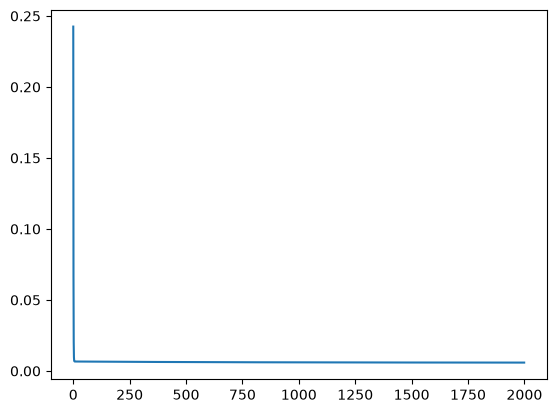

In [272]:
coeffs = train_model(2000, 0.05)

In [273]:
r2(coeffs)

TypeError: r2() missing 2 required positional arguments: 'indep' and 'dep'

In [274]:
print(calc_preds(coeffs, val_indep).shape, val_dep.shape)

torch.Size([25, 1]) torch.Size([25, 1, 1])


In [275]:
def r2(coeffs, indep, dep):
    return 1 - ((((calc_preds(coeffs, indep) - dep)**2).sum()) / (((dep - dep.mean())**2).sum()))

print("Train R²:", r2(coeffs, trn_indep, trn_dep))
print("Val R²:", r2(coeffs, val_indep, val_dep))

Train R²: tensor(-77.7397, device='cuda:0', grad_fn=<RsubBackward1>)
Val R²: tensor(-100.0684, device='cuda:0', grad_fn=<RsubBackward1>)


In [276]:
print(trn_indep.mean(), trn_indep.std())
print(val_indep.mean(), val_indep.std())

tensor(0.9051, device='cuda:0') tensor(0.1005, device='cuda:0')
tensor(0.9360, device='cuda:0') tensor(0.0952, device='cuda:0')


In [277]:
print(trn_indep.shape, val_indep.shape)  # should both be (n, 1)

torch.Size([78, 1]) torch.Size([25, 1])


In [278]:
print(coeffs[0].shape)  # layer1: should be (1, n_hidden)

torch.Size([1, 4])


In [279]:
print(torch.corrcoef(torch.stack([trn_indep.squeeze(), trn_dep.squeeze()]))[0,1])

tensor(-0.8260, device='cuda:0')


In [280]:
print("trn_dep var:", trn_dep.var().item())
print("Final training loss:", 0.007)  # from your curve
print("Expected R² ≈", 1 - 0.007/trn_dep.var().item())

trn_dep var: 0.0059269145131111145
Final training loss: 0.007
Expected R² ≈ -0.18105297191567038


In [281]:
mean_a = trn_dep[trn_indep.squeeze()==0.8].mean()
mean_b = trn_dep[trn_indep.squeeze()==1.0].mean()
naive_preds = torch.where(trn_indep.squeeze()==0.8, mean_a, mean_b)
naive_mse = ((naive_preds - trn_dep.squeeze())**2).mean()
print("Naive group-mean MSE:", naive_mse.item())
print(mean_a, mean_b)

Naive group-mean MSE: 0.001858878182247281
tensor(0.9410, device='cuda:0') tensor(0.8144, device='cuda:0')


In [282]:
print(calc_preds(coeffs, trn_indep)[:10].squeeze())
print(trn_dep[:10].squeeze())

tensor([0.8665, 0.8814, 0.8814, 0.8665, 0.8814, 0.8814, 0.8665, 0.8665, 0.8665, 0.8814], device='cuda:0', grad_fn=<SqueezeBackward0>)
tensor([0.9632, 0.8902, 0.8901, 0.9865, 0.8898, 0.8900, 0.9713, 0.9458, 0.9834, 0.8901], device='cuda:0')


In [283]:
loss = calc_loss(coeffs, trn_indep, trn_dep)
loss.backward()
print(coeffs[0].grad)  # layer1 gradient
print(coeffs[1].grad)  # layer2 gradient
coeffs[0].grad.zero_(); coeffs[1].grad.zero_()  # reset since we're just inspecting

tensor([[-0.0001, -0.0003,  0.0007,  0.0006]], device='cuda:0')
tensor([[-0.0006],
        [ 0.0002],
        [ 0.0002],
        [-0.0004]], device='cuda:0')


tensor([[0.],
        [0.],
        [0.],
        [0.]], device='cuda:0')